#### IMMUN 306QC
# Bulk RNA sequencing analysis
*Ralph Estanboulieh (2026)*

*This notebook was created **without** the use of AI.*

In this session, we will learn about the analysis of bulk RNA sequencing data. Unlike single-cell sequencing, which produces single-cell resolution data, bulk RNA sequencing produces sample-level data which represents the average transcriptome of all cells in the sample. While bulk sequencing is much less sensitive than single-cell sequencing (e.g. you need a lot more mRNA molecules of a gene to detect its expression), it is still a powerful and very cheap tool which, if done properly, can be effectively used to compare different samples with different treatments and conditions.

##### Learning goals
1. Differential gene expression analysis with PyDESeq2
2. Dimensionality reduction for bulk sequencing data
3. Gene set enrichment and gene ontology analysis

## RNA-seq data sets and where to find them

Bulk RNA sequencing returns a data set of sequenced reads, these reads are then mapped to the genome, assigned to protein transcripts/isoforms, and then returned as a matrix of raw read counts that looks like this (or a transpose of this):

| | sample_1 | sample_2 | sample_3 | ...|
|--- | --- | --- | --- |---|
| gene_1 | ||||
| gene_2 | ||||
| gene_3 | ||||
| ... | ||||

In this course, we will only deal with the analysis steps that follow the generation of the raw read counts. Although there is a very wide variety of powerful software packages that deal with the preceding mapping and counting steps, such as Bowtie2, STAR, HiSAT2, kallisto and countless others (the possibilities are endless, just check out [this Wikipedia page](https://en.wikipedia.org/wiki/List_of_RNA-Seq_bioinformatics_tools#Alignment_tools)), but these are out of the scope of this exercise. 

There are many places from which to download bulk and single-cell RNA sequencing data (and many other types of data too), many of them are listed in [this online blog post](https://bigomics.ch/blog/ultimate-guide-to-public-rnaseq-and-sc-rna-seq-databases/). Here's a brief description of some of the major sources:

| Database | Description |
| --- | --- |
|  [NCBI SRA](https://www.ncbi.nlm.nih.gov/sra)   |  Sequence Read Archive: the largest repository of raw, unprocessed FASTQ <br>sequencing files (DNA and RNA) for almost all published research |   
|  [NCBI GEO](https://www.ncbi.nlm.nih.gov/gds)   |  Gene Expression Omnibus: contains curated and processed gene expression <br>data, mostly as bulk and single-cell RNA sequencing, but also epigenetic and <br>proteomic profiling modalities. Best place to find raw gene count data sets. <br>GEO and SRA host most of the data sets listed below.|    
|  [TCGA](https://www.cancer.gov/ccg/research/genome-sequencing/tcga)   |  The Cancer Genome Atlas: massive repository of genomic, epigenomic, <br>transcriptomic, and proteomic data from 20,000 samples of 33 cancer types. <br>Allows users to "build" their own cohort based on many criteria. |     
|  [GTEx](https://gtexportal.org/home/) |  Genotype-Tissue Expression: bulk and single-cell gene expression data from <br>different tissues, along with genotype and (protected access) phenotype <br>information.|        
|  [ImmGen](https://www.immgen.org/Databrowser19/DatabrowserPage.html)   |  The Immunological Genome project: transcriptomic and other data specific to <br>the immune system.   |     
|  [Recount3](https://rna.recount.bio/)   |  Repository of bulk and single-cell RNA sequencing data sets that have been <br>uniformly processed according to a published protocol. Useful for browsing.  |     
|  [ENCODE](https://www.encodeproject.org/)   |  Encyclopedia of DNA Elements consortium: mainly epigenomic and regulatory <br>(not transcriptomic) data sets | 


## Downloading the data

We will be working with a data set of 288 samples and 18838 genes from [Furusawa et al. (2020)](https://pmc.ncbi.nlm.nih.gov/articles/PMC7667907/), titled "Chronic Hypersensitivity Pneumonitis, an Interstitial Lung Disease with Distinct Molecular Signatures", published in the American Journal of Respiratory and Critical Care Medicine. In this study, the authors collect lung biopsies from a cohort of 103 healthy individuals, 103 patients with idiopathic pulmonary fibrosis (IPF), and 82 patients with chronic hypersensitivity pneumonitis (CHP).

To download the data, we first need the GEO data set ID, which is usually listed somewhere in the paper (in this case the Methods section). We find that it is: GSE150910. GSE codes are GEO codes for Series. Usually, each Series is associated with a study, and occasionally a study might be associated with multiple series, in which case it is called a super Series. If we go to the GEO page that corresponds to GSE150910, we find the page shown below. Take your time to familiarize yourself with it.

<center><img src="geo_gsepage.png" width=700></center>

This study contains 288 samples (as expected), each labeled with a GSM code (GSE for Series, GSM for samples). To download the actual data, you can directly click on `GSE150910_gene-level_count_file.csv.gz` under Supplementary File at the very bottom of the page. However, it is good practice to, when possible and convenient, download the data directly from the URL as a step in your code. This makes it easier to keep track of your source and other useful information. To download data from a URL using a Linux operating system (like the Terminal on Mac computers), use `wget <url>`, replacing `<url>` with the internet link to the data file (which you can easily get by right-clicking and copying the link address). You can actually run Terminal commands directly in Jupyter notebooks using `!`:

In [161]:
! wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE150nnn/GSE150910/suppl/GSE150910%5Fgene%2Dlevel%5Fcount%5Ffile%2Ecsv%2Egz

--2026-10-08 14:29:50--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE150nnn/GSE150910/suppl/GSE150910%5Fgene%2Dlevel%5Fcount%5Ffile%2Ecsv%2Egz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 2607:f220:41e:250::11, 2607:f220:41e:250::7, 130.14.250.12, ...
connected. to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|2607:f220:41e:250::11|:443... 
200 OKequest sent, awaiting response... 
Length: 8117424 (7.7M) [application/x-gzip]
Saving to: ‘GSE150910_gene-level_count_file.csv.gz’

GSE150910_gene-leve 100%[===================>]   7.74M  17.2MB/s    in 0.4s    

2026-10-08 14:29:50 (17.2 MB/s) - ‘GSE150910_gene-level_count_file.csv.gz’ saved [8117424/8117424]



Great! We now have the data in hand — but it is compressed (notice the `.gz` suffix), so let's unzip it with `gunzip`:

In [162]:
! gunzip GSE150910_gene-level_count_file.csv.gz

While we're at it, let's install some useful packages we will need later:

In [ ]:
pip install pydeseq2

In [ ]:
pip install adjustText

Now that the data is downloaded and de-compressed, let's take a look at it with Pandas.

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi']=300

In [599]:
counts = pd.read_csv("GSE150910_gene-level_count_file.csv")
counts

,symbol,chp_26,chp_31,chp_34,chp_38,chp_1,chp_3,chp_4,chp_11,chp_5,...,chp_106,chp_108,chp_109,chp_110,chp_111,chp_112,chp_113,chp_114,ipf_1125,ipf_1130
0,TSPAN6,1361,993,351,613,841,565,1093,6239,1714,...,466,638,334,349,778,872,693,465,639,944
1,TNMD,5,13,0,0,0,6,3,4,0,...,0,0,0,0,0,0,0,0,0,0
2,DPM1,1929,2775,1894,2007,1436,1923,1956,4518,2411,...,936,1162,1043,689,1006,870,1701,860,1387,2150
3,SCYL3,176,216,208,218,162,137,242,490,259,...,57,35,122,42,73,68,145,21,146,204
4,C1orf112,93,143,97,148,98,128,102,188,119,...,50,60,72,21,74,48,131,72,69,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18833,AC055839.2,759,354,202,358,756,719,595,2333,936,...,410,570,649,454,894,760,1086,513,313,520
18834,AC242843.1,27,37,71,84,29,41,45,79,41,...,8,21,16,12,5,10,18,20,48,40
18835,SPDYE17,3,1,3,2,3,3,3,8,4,...,0,1,2,2,3,0,3,3,3,5
18836,AC022137.3,71,51,60,106,26,42,50,68,43,...,16,36,60,46,25,19,27,19,37,63


18,838 rows and 289 columns. Impressive! (You will find Pandas can efficiently handle even more, but of course that also depends on your computer's RAM size.) To make downstream calculations easier, let's set the gene names (column `symbol`) as the index so the DataFrame is entirely numbers and we can do math with it.

In [600]:
counts = counts.set_index('symbol')
counts

,chp_26,chp_31,chp_34,chp_38,chp_1,chp_3,chp_4,chp_11,chp_5,chp_9,...,chp_106,chp_108,chp_109,chp_110,chp_111,chp_112,chp_113,chp_114,ipf_1125,ipf_1130
symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1361,993,351,613,841,565,1093,6239,1714,1044,...,466,638,334,349,778,872,693,465,639,944
TNMD,5,13,0,0,0,6,3,4,0,0,...,0,0,0,0,0,0,0,0,0,0
DPM1,1929,2775,1894,2007,1436,1923,1956,4518,2411,2056,...,936,1162,1043,689,1006,870,1701,860,1387,2150
SCYL3,176,216,208,218,162,137,242,490,259,162,...,57,35,122,42,73,68,145,21,146,204
C1orf112,93,143,97,148,98,128,102,188,119,87,...,50,60,72,21,74,48,131,72,69,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC055839.2,759,354,202,358,756,719,595,2333,936,399,...,410,570,649,454,894,760,1086,513,313,520
AC242843.1,27,37,71,84,29,41,45,79,41,34,...,8,21,16,12,5,10,18,20,48,40
SPDYE17,3,1,3,2,3,3,3,8,4,3,...,0,1,2,2,3,0,3,3,3,5


Let's quickly explore the sample names. We can immediately tell that `chp` and `ipf` stand for chronic hypersensitivity pneumonitis and idiopathic pulmonary fibrosis, respectively. Let's count them using Pandas string methods.

In [601]:
counts.columns.str.split('_').str[0].value_counts()

ipf        103
control    103
chp         82
Name: count, dtype: int64

Just as expected!

## Getting the metadata

Now, before we start playing with the data, let's download the metadata, that is, the extra information associated with each sample. The paper mentions a few important attributes like age, sex, batch, location, immunosuppressant use, among others. This information usually exists in the Series matrix file. Let's download it and look at it:  

In [292]:
! wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE150nnn/GSE150910/matrix/GSE150910_series_matrix.txt.gz

--2026-10-09 00:16:17--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE150nnn/GSE150910/matrix/GSE150910_series_matrix.txt.gz
2607:f220:41e:250::10, 2607:f220:41e:250::13, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|2607:f220:41e:250::10|:443... connected.
200 OKequest sent, awaiting response... 
Length: 11145 (11K) [application/x-gzip]
Saving to: ‘GSE150910_series_matrix.txt.gz.1’

GSE150910_series_ma 100%[===================>]  10.88K  --.-KB/s    in 0s      

2026-10-09 00:16:18 (72.3 MB/s) - ‘GSE150910_series_matrix.txt.gz.1’ saved [11145/11145]



In [8]:
! gunzip GSE150910_series_matrix.txt.gz

GSE150910_series_matrix.txt already exists -- do you wish to overwrite (y or n)? ^C


Now open the file `GSE150910_series_matrix.txt` and look at it. Looks weird, right? And it doesn't even have the matrix data! The reason for this is history. This format was first developed to contain microarray data and metadata. But now, since most of the data sets on GEO are sequencing read counts, the Series matrix only contains metadata, while the actual data is listed under Supplementary Files.

Because the format of this text file is very peculiar and specialized, Pandas cannot read it with its native functions, so I coded up a simple function that quickly goes over the file line by line and cleans up and saves the relevant data as a Python dictionary, before converting that dictionary to a Pandas DataFrame:

In [548]:
def read_series_matrix(file_path):
    """
    Helper function. Parses "series matrix" .txt file from the GEO database.
    Only keeps lines that start with "!Sample_".
    Separates sample "characteristics" by characteristic.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()  # read lines separately
        
    meta_dict = {}  # initialize dictionary for metadata collection
    
    for l in lines:
        if l[:8] == "!Sample_":
            items = [i.strip("\n\"") for i in l.split('\t')]  # split the row items and strip them of quotes and \n
            col_name = items[0].split('_')[1]                 # column name is the first item of the row
            data = items[1:]                                  # data is the rest of the row
            if col_name.split('_')[0] == 'characteristics':   # extra metadata are all listed as "characteristics" and need processing
                col_name = data[0].split(": ")[0]
                data = [d[(len(col_name)+2):] for d in data]
            meta_dict[col_name] = data
    
    print("Metadata extracted:\n- " + '\n- '.join(meta_dict.keys()))

    return pd.DataFrame.from_dict(meta_dict)

In [549]:
meta = read_series_matrix('GSE150910_series_matrix.txt')

Metadata extracted:
- title
- geo
- status
- submission
- last
- type
- channel
- source
- organism
- tissue
- Sex
- age
- diagnosis
- ever_smoked
- race (hispanic;1, black;3,asian;4, white;5, other;6)
- rs35705950_genotype
- sample type
- psl
- is
- antigen_identified
- batch
- lane
- plate
- institution
- molecule
- extract
- taxid
- data
- platform
- contact
- instrument
- library
- relation
- supplementary


Now, for each sample, we have metadata that could prove very useful in our downstream analysis. But before it is ready to be used, let's clean it up a little bit by (1) renaming columns, (2) only selecting relevant columns, and (3) adjusting the data types to Categorical for all columns but age and sample name (right now, all the data types are strings).

In [550]:
meta

,title,geo,status,submission,last,type,channel,source,organism,tissue,...,molecule,extract,taxid,data,platform,contact,instrument,library,relation,supplementary
0,chp_1,GSM4560505,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
1,chp_2,GSM4560506,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
2,chp_3,GSM4560507,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
3,chp_4,GSM4560508,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
4,chp_5,GSM4560509,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,ipf_1170,GSM4560788,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
284,ipf_1172,GSM4560789,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
285,ipf_1176,GSM4560790,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE
286,ipf_1181,GSM4560791,Public on Jul 01 2020,May 20 2020,Jul 01 2020,SRA,1,Human lung,Homo sapiens,lung tissue,...,polyA RNA,"To establish RNA library, we used TruSeq Stra...",9606,0,GPL24676,USA,Illumina NovaSeq 6000,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE


In [553]:
# renaming some columns
meta = meta.rename(columns = {
    'title': 'sample',
    'Sex': 'sex',
    'race (hispanic;1, black;3,asian;4, white;5, other;6)': 'race', 
    'rs35705950_genotype': 'genotype', 
    'psl': 'steroids', 
    'is': 'immunsup',
    'sample type': 'sample_type'
})

# selecting only relevant columns
meta = meta[['sample', 'sex', 'age', 'diagnosis', 'ever_smoked', 'race', 'plate', 'institution', 'sample_type']]

# denoting missing data
meta = meta.replace(['NA', 'unknown', 'UNKNOWN'], np.nan)

# make all columns categorical...
meta = meta.astype('category')

# ... except age and title (which can remain of type string)
meta['age'] = meta['age'].astype('Int16')
meta['sample'] = meta['sample'].astype('str')

In [554]:
meta.dtypes

sample              str
sex            category
age               Int16
diagnosis      category
ever_smoked    category
race           category
plate          category
institution    category
sample_type    category
dtype: object

Now that the metadata is organized and of the correct types, it is always encouraged to do a few sanity checks. For instance, let's check that the cohorts are age-matched (as they should be, according to the authors):

In [555]:
meta.groupby('diagnosis')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
chp,81.0,59.407407,10.56501,28.0,55.0,61.0,66.0,79.0
control,103.0,59.854369,10.164729,28.0,53.5,61.0,67.0,79.0
ipf,102.0,60.303922,8.265147,37.0,54.25,61.0,66.0,80.0


It seems like there is a lot of missing data regarding treatment with immunosuppressants, so we will not use it in this analysis.

## Basic data analysis and cleanup

Let's explore our data a little bit. First, let's look at the total read counts per sample and per gene, which can give us a sense of sequencing depth.

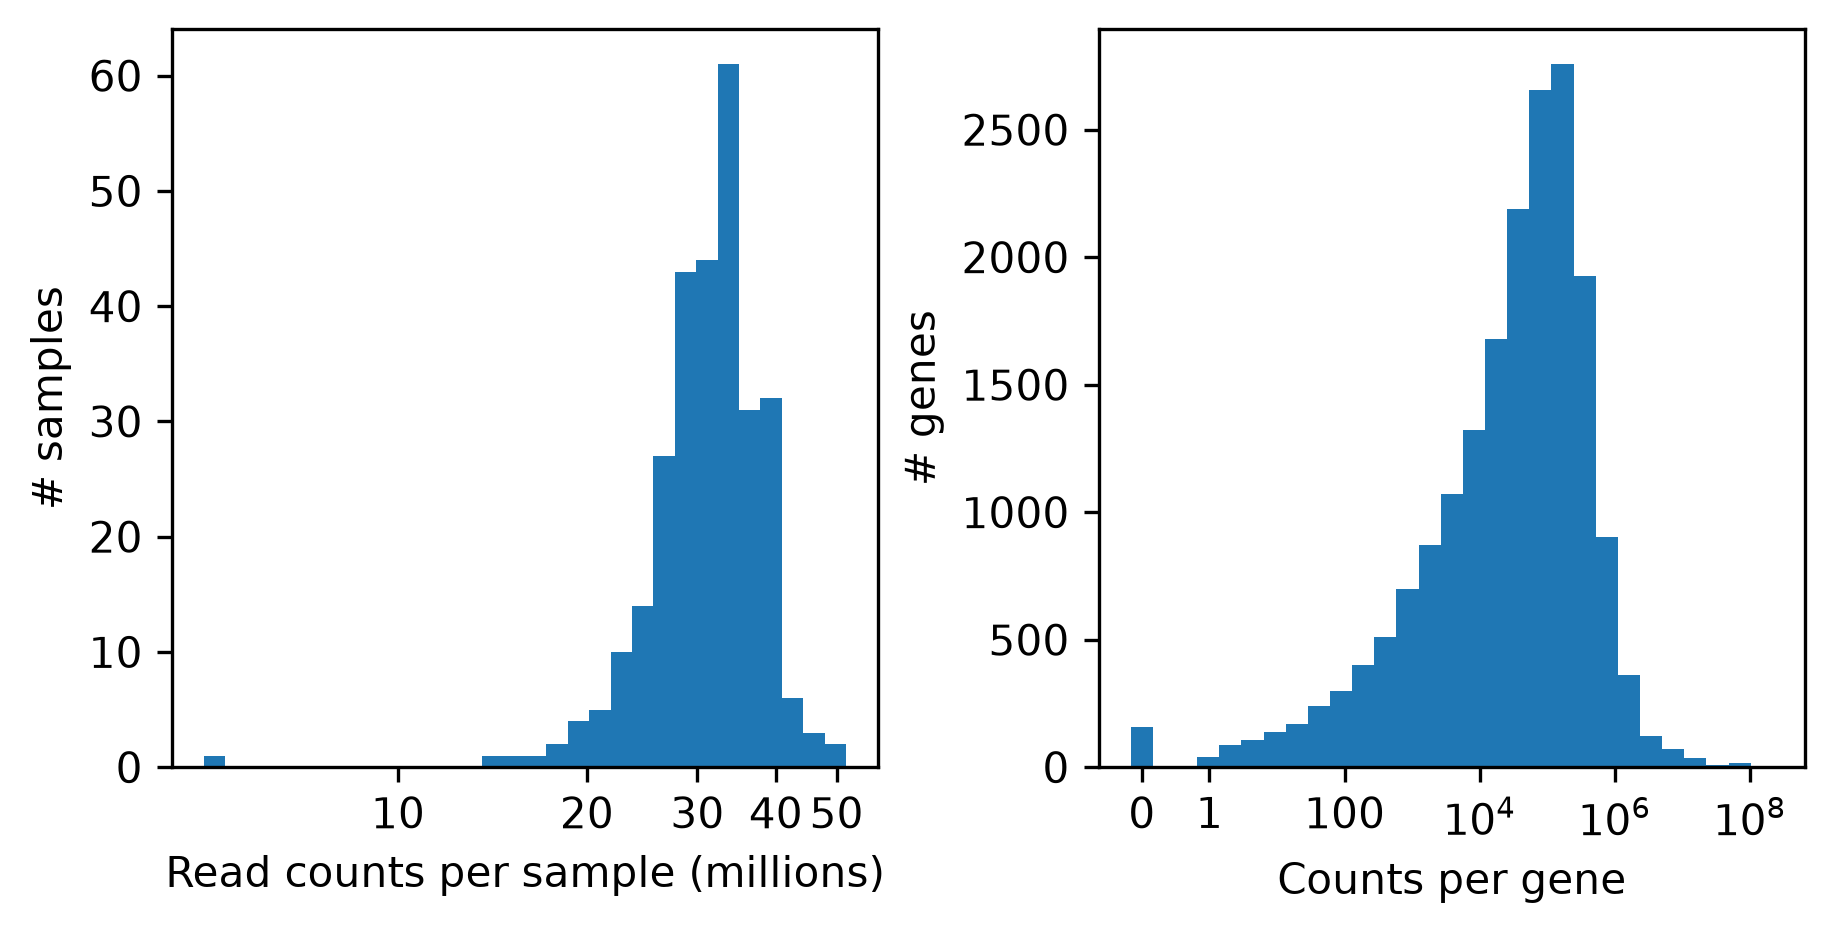

In [602]:
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')
ax = axs[0]
ax.hist(np.log10(counts.sum(axis=0)), bins=30)
x = np.arange(10e6, 60e6, 10e6)
ax.set_xticks(ticks=np.log10(x), labels = ['10', '20', '30', '40', '50'])
ax.set(xlabel='Read counts per sample (millions)', ylabel='# samples')

ax = axs[1]
ax.hist(np.log10(counts.sum(axis=1)+0.1), bins=np.linspace(-1, 8.5, 30), align='left')
ax.set(xlabel = 'Counts per gene', ylabel='# genes')
ax.set_xticks([-1, 0, 2, 4, 6, 8], labels=[0, 1, 100, r"$10^4$", r"$10^6$", r"$10^8$"]);

As you can see, not all samples have the same number of counts (aka library size). This could be due to technical and/or biological reasons, and it can become a problem with downstream analysis, as it can significantly bias results. We address this the process of **normalization**. There are many ways to normalize data, with some more popular than others, but the software we will be using later has its own normalization algorithm.

Another observation is that some genes are way more expressed than others. Because bulk RNA sequencing is done in bulk, its sensitivity drops dramatically when it comes to lowly expressed genes. While it is easy to discard all genes with 0 expression, it is much harder to define a threshold of expression below which gene should also be discarded. For now, the most conservative approach would be to discard only the genes with <20 total read counts:

In [603]:
counts = counts[counts.sum(axis=1) > 1]
counts

,chp_26,chp_31,chp_34,chp_38,chp_1,chp_3,chp_4,chp_11,chp_5,chp_9,...,chp_106,chp_108,chp_109,chp_110,chp_111,chp_112,chp_113,chp_114,ipf_1125,ipf_1130
symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1361,993,351,613,841,565,1093,6239,1714,1044,...,466,638,334,349,778,872,693,465,639,944
TNMD,5,13,0,0,0,6,3,4,0,0,...,0,0,0,0,0,0,0,0,0,0
DPM1,1929,2775,1894,2007,1436,1923,1956,4518,2411,2056,...,936,1162,1043,689,1006,870,1701,860,1387,2150
SCYL3,176,216,208,218,162,137,242,490,259,162,...,57,35,122,42,73,68,145,21,146,204
C1orf112,93,143,97,148,98,128,102,188,119,87,...,50,60,72,21,74,48,131,72,69,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC055839.2,759,354,202,358,756,719,595,2333,936,399,...,410,570,649,454,894,760,1086,513,313,520
AC242843.1,27,37,71,84,29,41,45,79,41,34,...,8,21,16,12,5,10,18,20,48,40
SPDYE17,3,1,3,2,3,3,3,8,4,3,...,0,1,2,2,3,0,3,3,3,5


To avoid using samples with missing metadata, let's create versions of these DataFrames without missing metadata:

In [561]:
# remove metadata rows with any missing values
meta_nona = meta[~meta.isna().any(axis=1)]

# keep samples consistent
counts_nona = counts[meta_nona['sample']]

Let's also reorder the samples in `counts` so they match the sample order in the metadata:

In [562]:
counts = counts[meta['sample']]

## The distribution of read counts

Like any random variable, read counts tend to follow a distribution. Since read counts are positive integers (and not decimals), there are two discrete distributions which could be used to fit such data: the Poisson and the Negative Binomial distributions. A major difference between the two is that while the mean and variance of a random variable are equal to each other in the Poisson case, they are allowed to be different in the Negative Binomial case. Let's check the relationship between the mean and the variance of each gene's read count in our dataset:

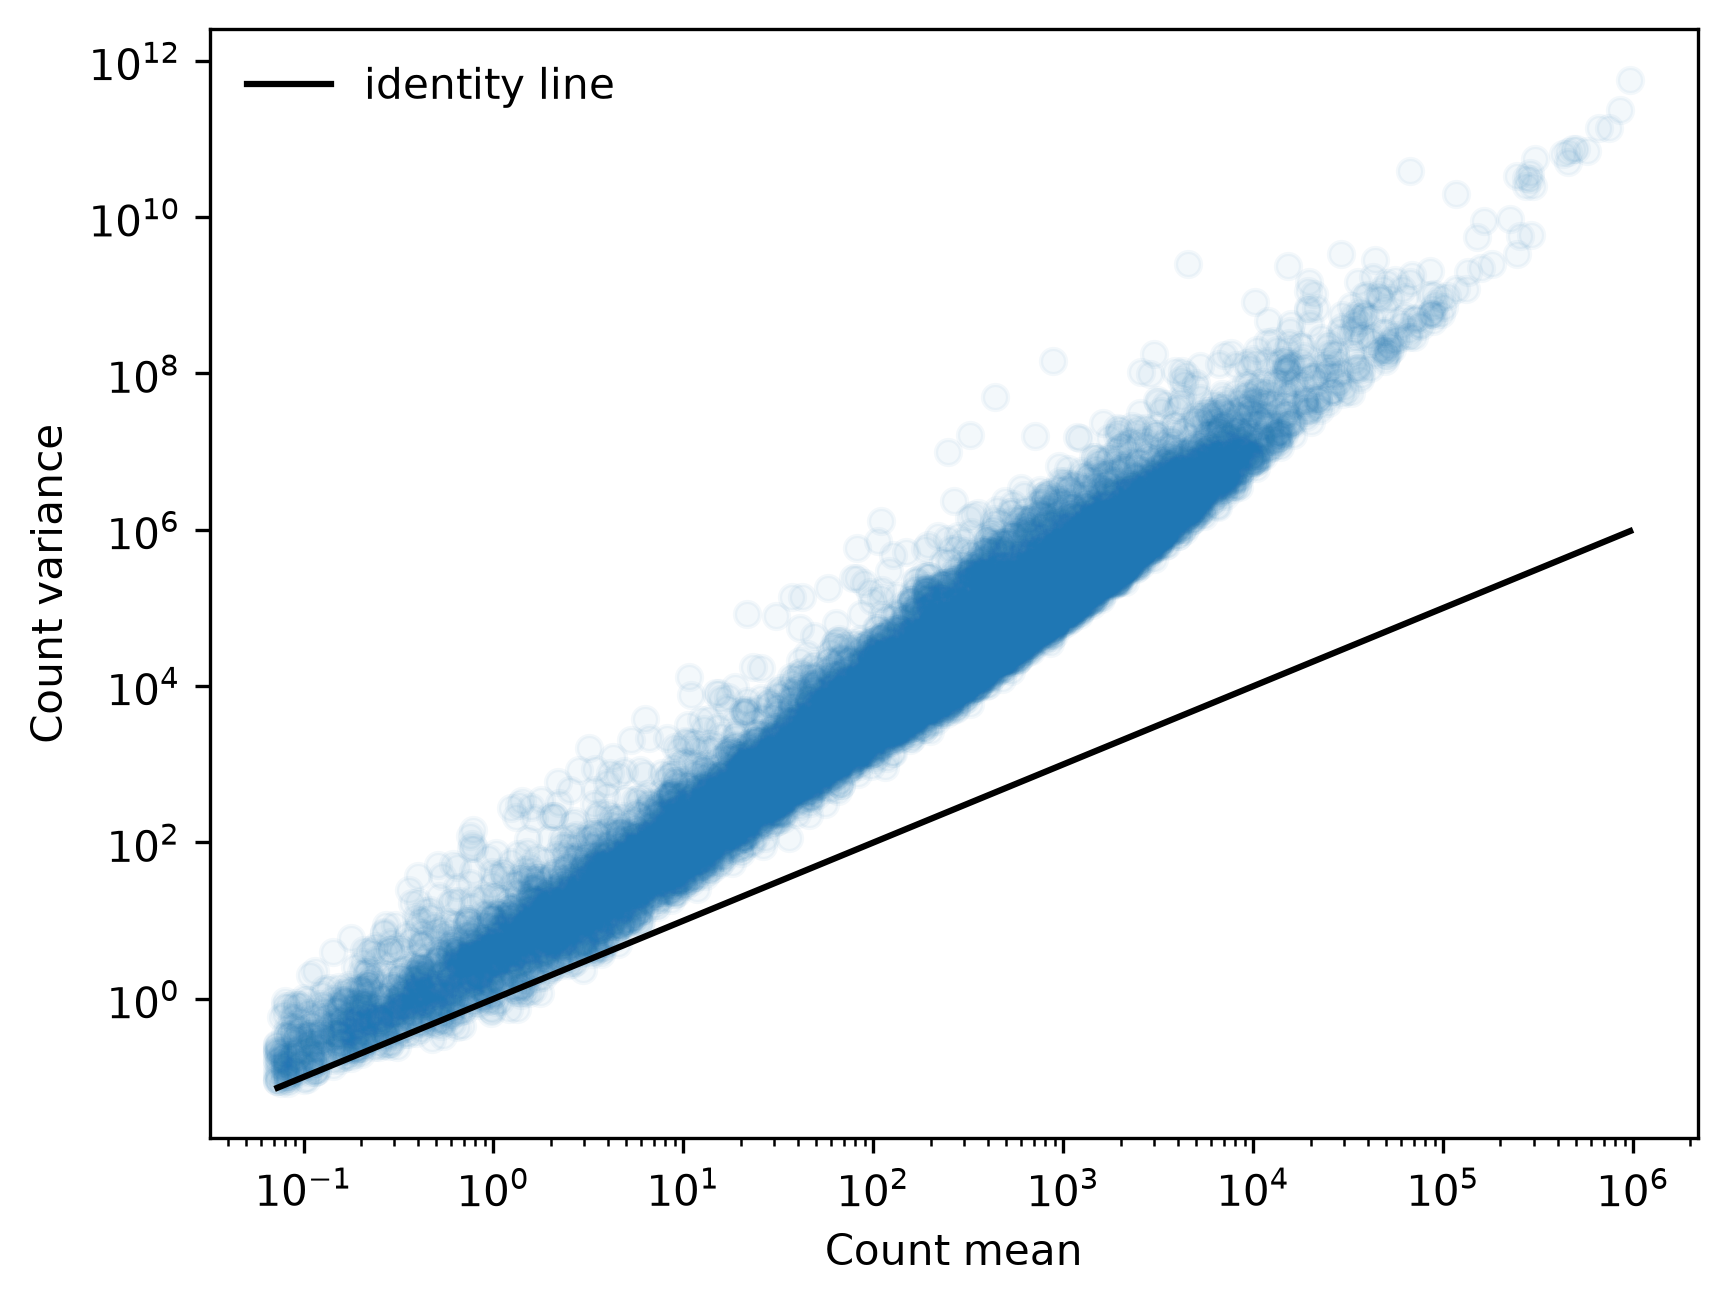

In [563]:
x, y = counts.mean(axis = 1), counts.var(axis=1)
plt.scatter(x, y, alpha=0.05)

# plot identity line to show equal mean and variance
id_line = np.arange(x.min(), x.max(), 1000)
plt.plot(id_line, id_line, c='k', label = 'identity line')

plt.xlabel('Count mean')
plt.ylabel('Count variance')
plt.legend(frameon=False)
plt.loglog();

We can clearly see that the variance is much higher than the mean in this case, which means that the Negative Binomial is likely a much better fit. This is exactly the assumption PyDESeq2 makes when estimating differential gene expression.

## Read count normalization

Because of the significant amount of noise that can permeate RNA seq data, most applications require some sort of normalization to account for a few sources of bias, the biggest of which include:
1) **Library size:** as we saw earlier, some samples may contain or capture way more reads than other samples, that makes it much harder to tell if a gene is differentially expressed because of the difference in expression (what we are interested in) or the difference in library size (the confounder we would like to avoid).
2) **Gene length:** during sequencing, longer genes yield more fragments to be sequenced, which can make larger genes appear to have higher expression levels.
3) **Library composition:** genes that very highly expressed can take over the sequencing "real estate" of other genes, making those genes appear to have lower expression levels than they actually do.

This is why we have normalization. Over the years, many normalization methods have been suggested. The most basic one is counts-per-million (CPM), which for gene $g$ in sample $k$ is:
$$CPM_g^k = \frac{X_g^k}{\sum_{g'} X_{g'}^k}$$
(Where $X_g^k$ is the read count for gene $g$ in sample $k$). However, it only addresses the library size concern and ignores the very significant effects of gene length and library composition. To address gene length-derived bias, the read-counts-per-kilobase-per-million (RPKM) was suggested, in which we first normalize by total library size, multiply by $10^6$ to make numbers look nicer, and then divide by transcript length $L_g$. However, this method returned unequal library sizes, which makes it hard to compare genes across different samples.

$$RPKM_g^k = \left(10^6\times\frac{X_g^k}{\sum_{g'} X_{g'}}\right)\times\frac{1}{L_g}$$

A better, more recent normalization metric is transcripts-per-million (TPM), which is similar to the RPKM except the order of operations is flipped: we first normalize by gene length and then by library size (and multiply by $10^6$ for nice-looking numbers). This ensures that all samples will have exactly $10^6$ total transcripts, making it much easier to compare gene expression across samples:

$$TPM_g^k = 10^6\times\frac{X_g^k/L_g}{\sum_{g'} X_{g'}^k/L_{g'}}$$

Of course, there are many more normalization methods. Another commonly used one is called the trimmed mean of M values (TMM), but we won't go into it. Software for RNA seq analysis sometimes come with their own optimized normalization methods, such as DESeq2, which uses a median of ratios method that also involves the geometric mean of the counts of a gene across all samples.


## Differential gene expression analysis with PyDESeq2

One very common application of bulk RNA sequencing is the comparison of different samples with different treatments and conditions. This can be useful to study the effect of a treatment on the expression of a set of genes or the abundance of a cell type. DESeq2 is an extremely popular R package that does just that, and PyDESeq2 is simply the Python adaptatation of DESeq2. The documentation for DESeq2 can easily be found [here](https://pydeseq2.readthedocs.io/en/latest/index.html), check it out!

The main outputs of PyDESeq2 are the log2 fold changes (log2FCs) and their associated p-values. In short, PyDESeq2 first normalizes the data with its own normalization algorithm, which returns **size factors** which correlate with the size of each sample; then, it fits Negative Binomial distributions to the read counts of each gene to find the dispersions; then, it fits a Negative Binomial-based generalized linear model based on the input model design; and finally, it computes the fold changes and the p-values using the Wald test. There is a lot more that goes into this, including some Bayesian statistics and p-value adjustment, but you don't have to worry about any of it! 

Let's do this step by step. It's actually pretty easy. First, let's import the relevant libraries:

In [564]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

Now, let's run the PyDESeq2 pipeline, which involves creating a `DeseqDataSet` object using the counts data and metadata we have. Notice that the counts should be `samples x genes` (rows, columns) rather than `genes x samples` as we have it so far, hence the transposition with `.T`. The `.sort_index()` is to ensure that the samples have the same order in both the counts data and metadata.

In [565]:
inference = DefaultInference(n_cpus=8) # cryptic, but necessary

In [689]:
dds = DeseqDataSet(
    counts=counts_nona.T,
    metadata=meta_nona.set_index('sample'),
    design="~diagnosis + sex + age + ever_smoked + race + plate + institution + sample_type",  # compare samples based on the "condition"
    refit_cooks=True,
    inference=inference
)

Now, the magic command:

In [691]:
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.32 seconds.

/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.py:230: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.py:382: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.py:385: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/Users/ralphestanboulieh/anaconda3/lib/python3.13/site-packages/pydeseq2/utils.

And that's almost it! Now that we have fitted the model, we can do statistical inference, that is, calculate the p-values based on **binary** comparisons. This can be done with the `DeseqStats` object, which takes as input the `DeseqDataSet`, the desired contrast (as a 3-item list of the form `[column_name, condition_A, condition_B]`), and a few other optional parameters, such as the significance threshold `alpha`, which is useful when performing p-value adjustment. For example, in the comparison below, we contrast the control and IPF conditions.

In [682]:
ds = DeseqStats(
    dds,
    contrast= ['diagnosis', 'ipf', 'control'],
    alpha=0.05
)

After setting things up, we can run the Wald tests using the method `summary()`

In [683]:
ds.summary()

Running Wald tests...
... done in 6.09 seconds.



Log2 fold change & Wald test p-value: diagnosis ipf vs control
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
symbol                                                                      
TSPAN6      1061.871362        0.695258  0.100303  6.931587  4.161440e-12   
TNMD           5.761079        0.159991  1.342479  0.119176  9.051361e-01   
DPM1        1922.804823        0.083246  0.050235  1.657123  9.749458e-02   
SCYL3        184.923745        0.061188  0.075169  0.813996  4.156470e-01   
C1orf112     103.286493        0.166899  0.058336  2.861007  4.222982e-03   
...                 ...             ...       ...       ...           ...   
AC055839.2   667.842464        0.436157  0.098600  4.423481  9.712313e-06   
AC242843.1    44.862890       -0.161550  0.096593 -1.672487  9.442841e-02   
SPDYE17        4.304871        0.508268  0.116190  4.374460  1.217334e-05   
AC022137.3    57.553045       -0.140100  0.076180 -1.839073  6.590446e-02   
AC007244.1   

The results are then stored in a DataFrame called `results_df`:

In [684]:
ds.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
symbol,,,,,,
TSPAN6,1061.871362,0.695258,0.100303,6.931587,4.161440e-12,5.574990e-11
TNMD,5.761079,0.159991,1.342479,0.119176,9.051361e-01,9.472174e-01
DPM1,1922.804823,0.083246,0.050235,1.657123,9.749458e-02,1.748653e-01
SCYL3,184.923745,0.061188,0.075169,0.813996,4.156470e-01,5.525855e-01
C1orf112,103.286493,0.166899,0.058336,2.861007,4.222982e-03,1.154475e-02
...,...,...,...,...,...,...
AC055839.2,667.842464,0.436157,0.098600,4.423481,9.712313e-06,4.653976e-05
AC242843.1,44.862890,-0.161550,0.096593,-1.672487,9.442841e-02,1.703509e-01
SPDYE17,4.304871,0.508268,0.116190,4.374460,1.217334e-05,5.732685e-05


### The `AnnData` object

Let's briefly look at the object returned by `DeseqDataSet`:

In [694]:
dds

AnnData object with n_obs × n_vars = 263 × 18300
    obs: 'sex', 'age', 'diagnosis', 'ever_smoked', 'race', 'plate', 'institution', 'sample_type', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: None (.X), 'normed_counts', '_mu_hat', 'cooks'

Curious! It identifies itself as `AnnData`, an powerful annotated data object which was created for high-throughput data analysis. It comes from the AnnData package (check out [the docs here](https://anndata.readthedocs.io/en/latest/)), which was automatically installed when we installed PyDESeq2 (because the latter depends on the former to work).

AnnData is a really neat way to have data and metadata all in one place. This is their schema (taken from their documentation):

<center><img src="anndata_schema.svg"></center>



An AnnData object contains the data itself (`X`, which can have any layers), but also multivariate metadata for both the samples and the features (e.g. genes and samples), in addition to unstructured data. Powerful stuff. We'll leave it at that for now, but we will see it again in the single-cell RNA seq analysis workshop. 

### Volcano plot

While we can manually look at the results DataFrame and browse through genes, a very useful visualization modality is the volcano plot, which plots the log2 fold changes against the adjusted p-values. Here's a minimal version of it:

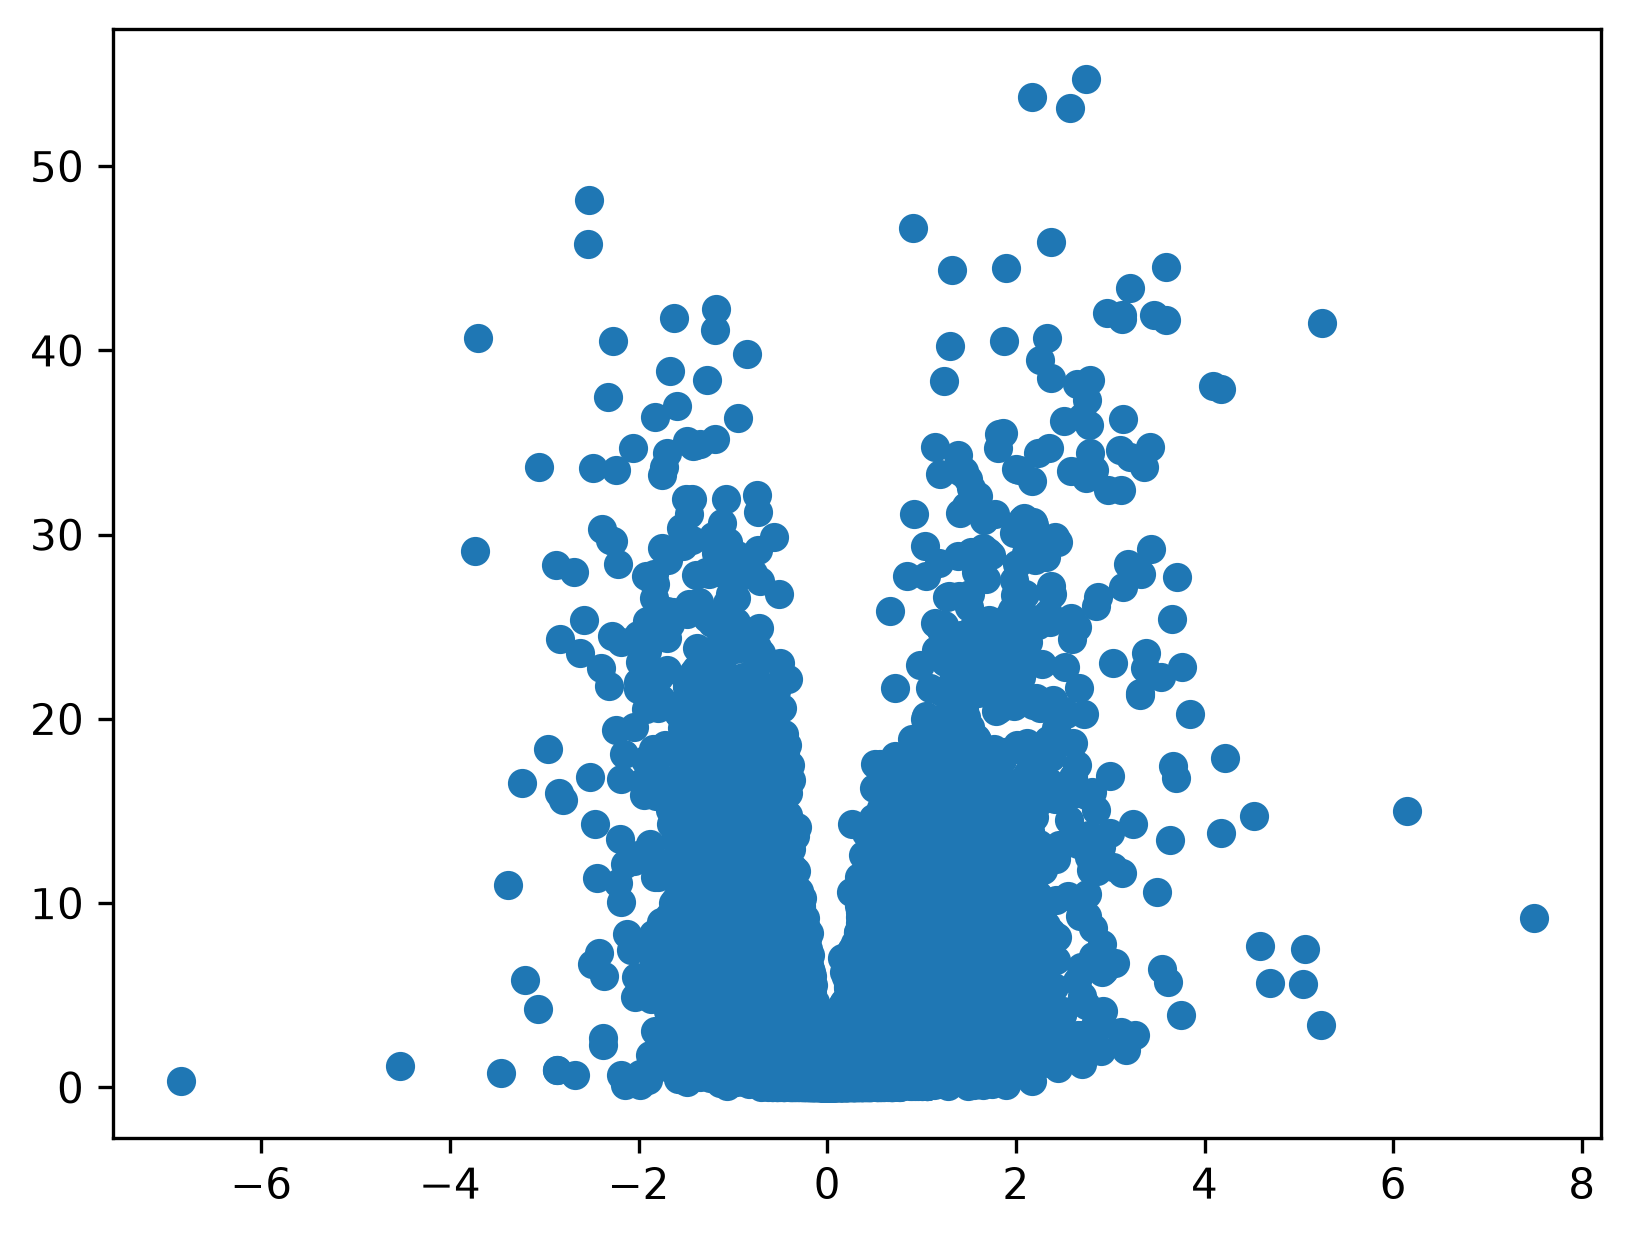

In [685]:
plt.scatter(ds.results_df['log2FoldChange'], -np.log10(ds.results_df['padj']));

Let's make it fancier:

In [686]:
# to plot non-overlapping text
from adjustText import adjust_text 

In [687]:
def fancy_volcano(df, thresh_fc = 2, thresh_p = 0.05, ax=None, title=None):
    if not ax: # create ax
        fig, ax = plt.subplots()

    # prep the colors according to padj and log2fc
    colors = pd.Series('tab:grey', index = df.index)
    colors[df['log2FoldChange'] > np.log2(thresh_fc)] = 'tab:blue'
    colors[df['log2FoldChange'] < -np.log2(thresh_fc)] = 'tab:red'
    colors[df['padj'] > thresh_p] = 'tab:grey'

    # plot
    ax.scatter(df['log2FoldChange'], -np.log10(df['padj']), c=colors, alpha = 0.5, ec='none', s=3);

    # label
    ax.set(
        xlabel = 'log2(fold change)',
        ylabel = '-log10(adjusted p-value)'
    )
    if title:
        ax.set_title(title)

    # add text
    texts = []
    top = df[colors=='tab:blue'].sort_values('log2FoldChange', ascending=False).iloc[:50]
    for row in top.itertuples():
        t = ax.text(row.log2FoldChange, -np.log10(row.padj), row.Index, fontsize=5, color='tab:blue')
        texts.append(t)

    bottom = df[colors=='tab:red'].sort_values('log2FoldChange', ascending=True).iloc[:50]
    for row in bottom.itertuples():
        t = ax.text(row.log2FoldChange, -np.log10(row.padj), row.Index, fontsize=5, color='tab:red', ha='right')
        texts.append(t)

    adjust_text(texts, ax=ax)

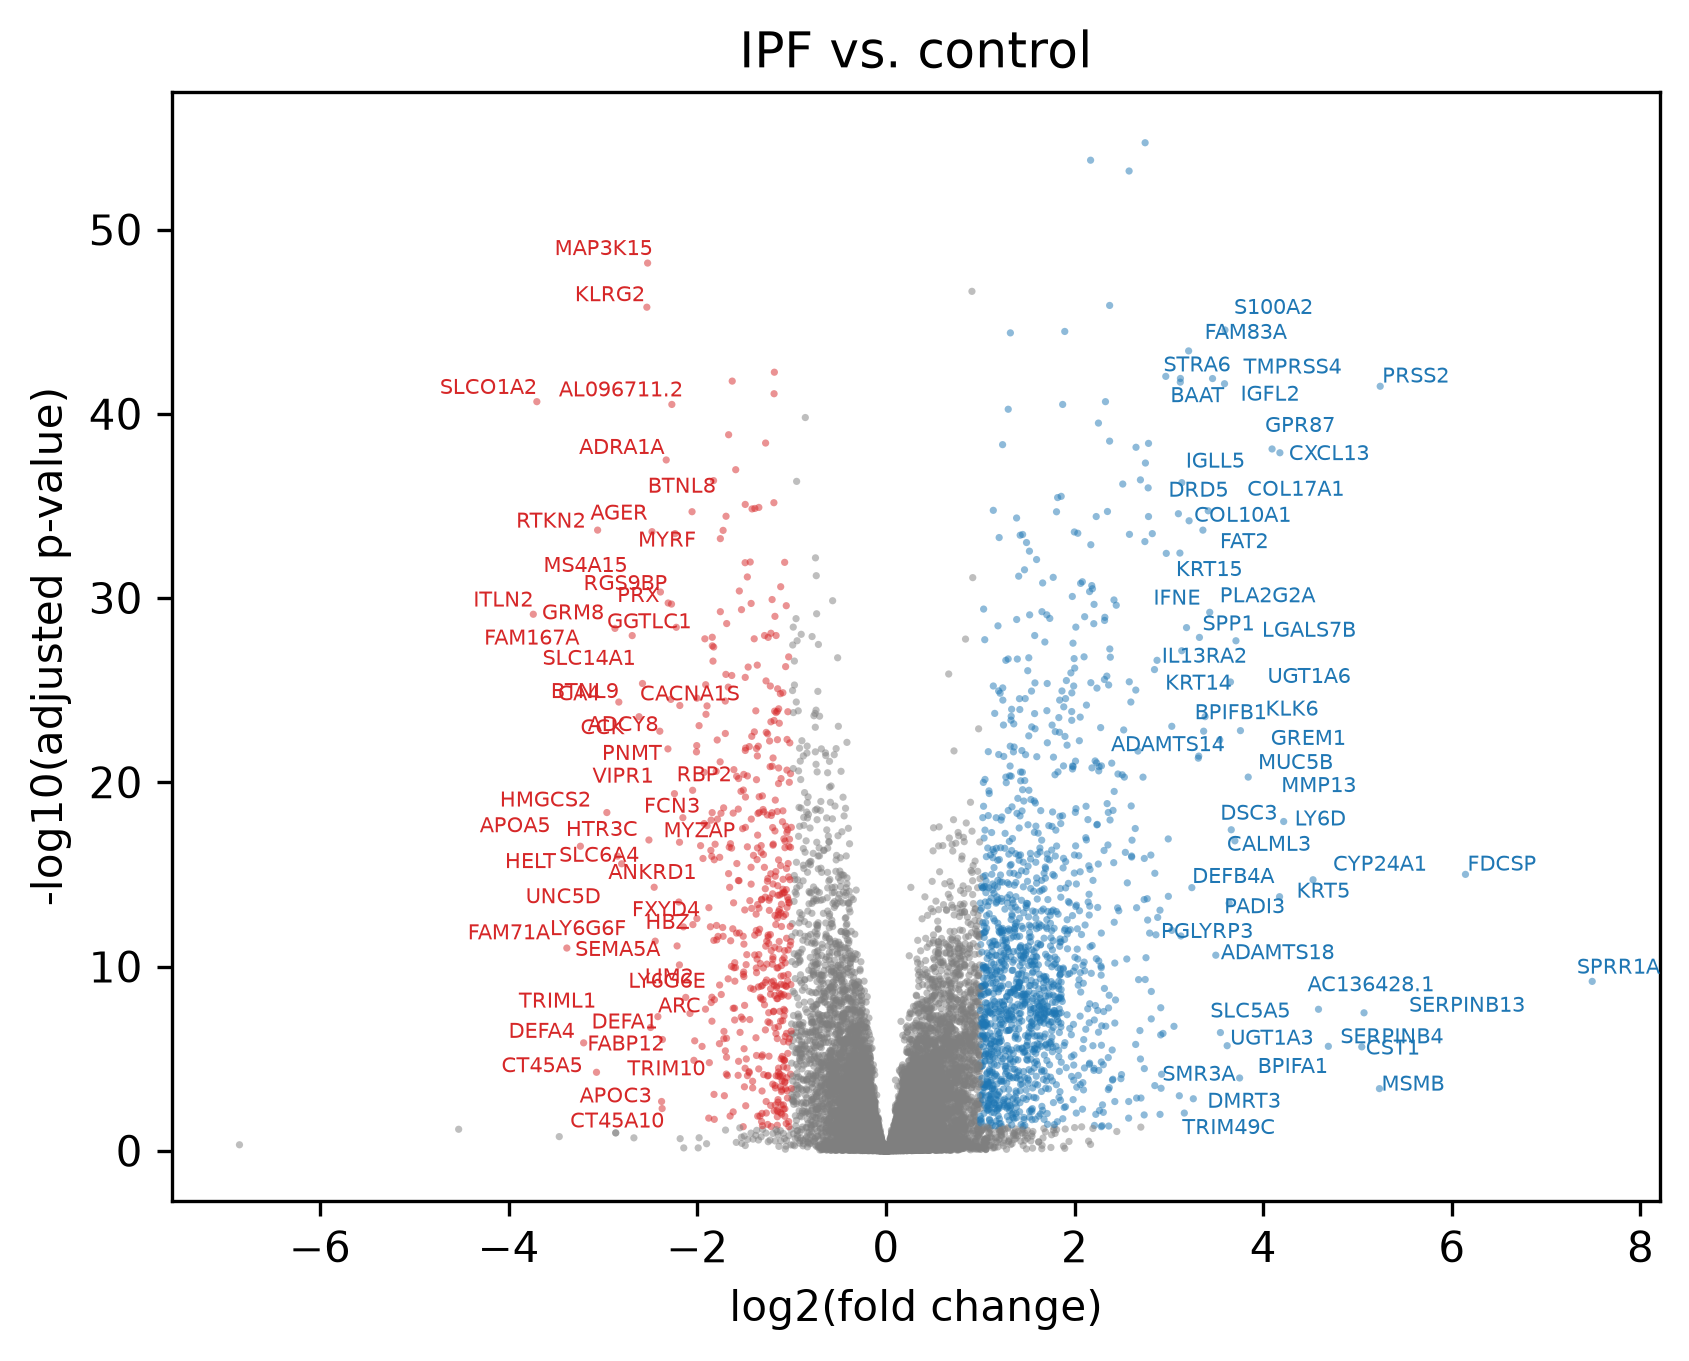

In [688]:
fancy_volcano(ds.results_df, title='IPF vs. control')

In [575]:
ds.results_df.sort_values('log2FoldChange', ascending=False).head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
symbol,,,,,,
SPRR1A,182.612370,7.478682,1.152293,6.490258,8.568933e-11,9.457869e-10
FDCSP,533.669667,6.094499,0.686651,8.875686,6.950360e-19,2.368558e-17
PRSS2,209.159652,5.231291,0.372454,14.045471,8.212033e-45,7.514010e-42
MSMB,342.528552,5.179366,1.341961,3.859550,1.135962e-04,4.444751e-04
CST1,126.447053,5.035641,0.995542,5.058191,4.232532e-07,2.565596e-06
AC136428.1,350.944224,4.508641,0.752220,5.993780,2.050183e-09,1.835536e-08
CYP24A1,261.570549,4.454643,0.543937,8.189631,2.620288e-16,6.445062e-15
CXCL13,960.765158,4.334386,0.308912,14.031133,1.005327e-44,8.760707e-42
LY6D,29.385948,4.210597,0.457290,9.207710,3.331564e-20,1.325383e-18


### MA plot

The MA plot is another useful visualization that graphs the mean of normalized counts versus the log2 fold change. PyDESeq2 has its own implementation of the MA plot in which red dots have significant p-values.

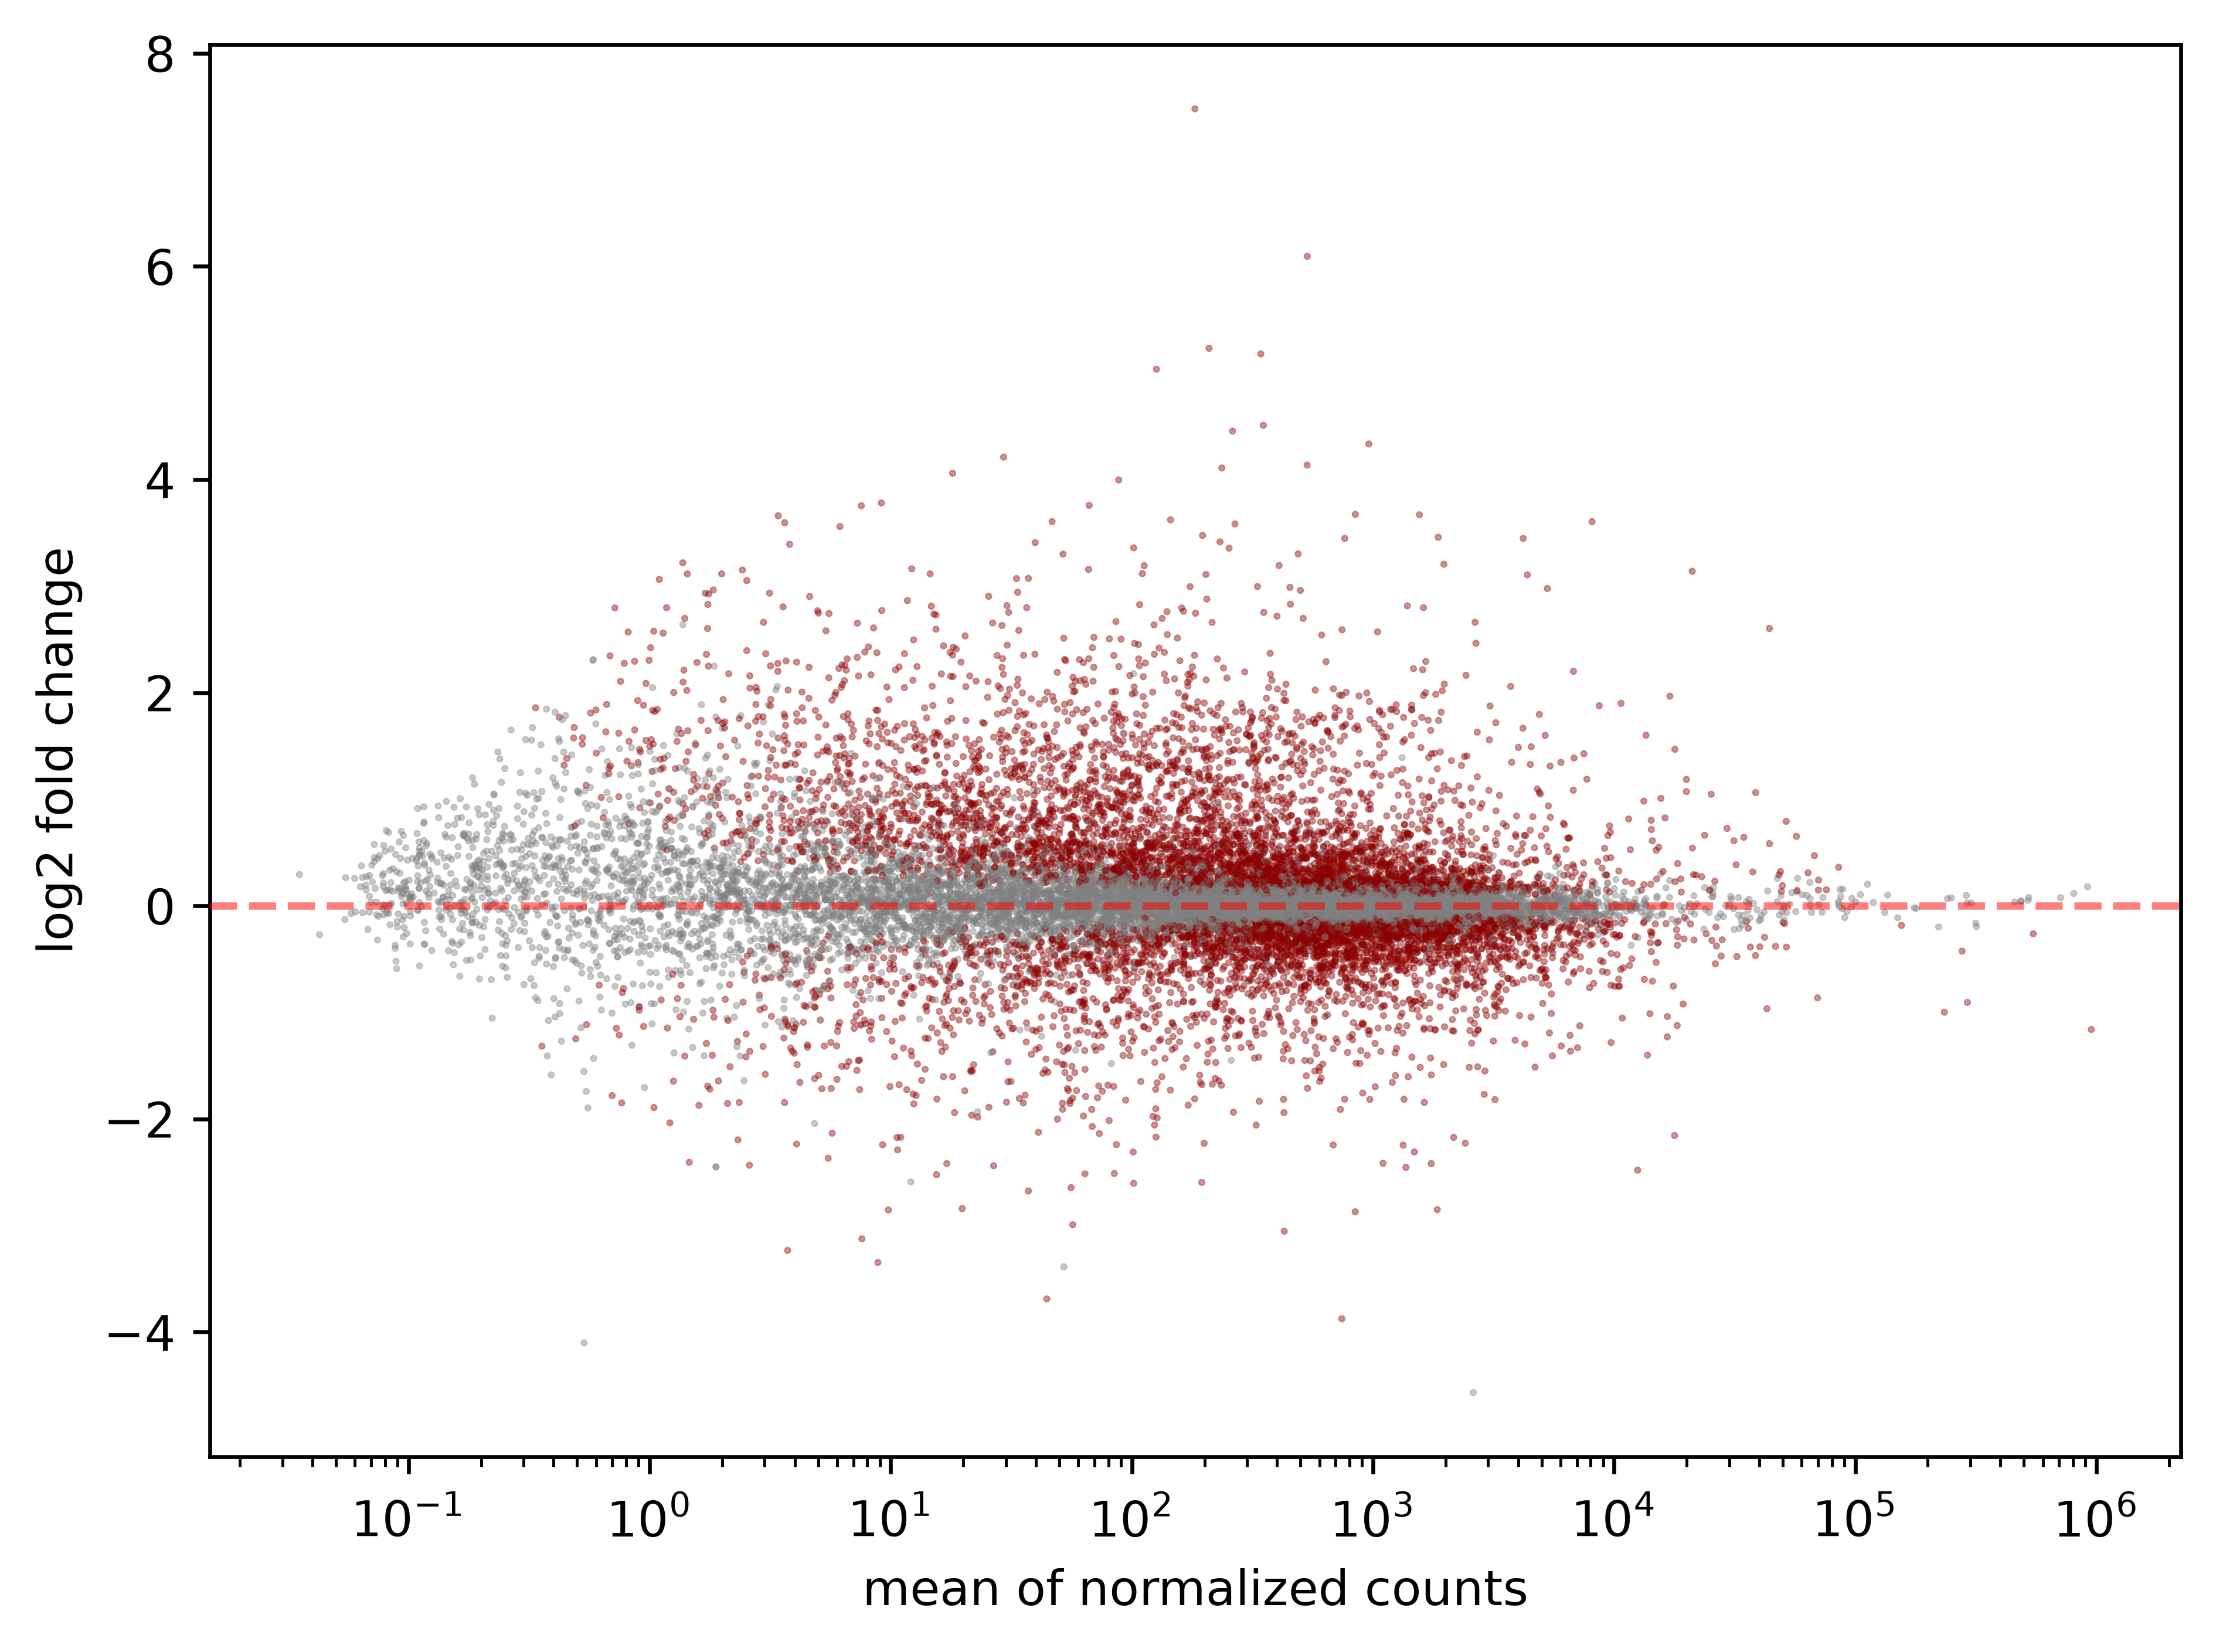

In [576]:
ds.plot_MA()

## Dimensionality reduction with PCA 

Of course, in addition to differential expression analysis, we might also simply want to *look* at the data. Not so simple! How do we look at 18,000-dimensional data points? We don't: we look at a lower dimensional "version" (aka embedding) of these data points. This is called **dimensionality reduction**. One of the most fundamental dimensionality reduction methods is principal component analysis, or PCA, which finds the 2D flat surface on which the projection of the data points has the most "spread" (variance, in statistical terms). But before we PCA, it is crucial to process our data by (1) normalizing samples by library size, (2) taking the log2, (3) centering and scaling (standardizing) our data so it has mean 0 and variance 1. Then, and only then, are we ready to play with PCA.

A very powerful package to do this kind of analysis is scikit-learn (or sklearn), from which we import the PCA and standard-scaling machinery:

In [577]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [613]:
def pca_embeddings(counts):
    '''
    Pre-processing and PCA embedding.
    `counts` is n_genes x n_samples.
    '''
    # normalize by library size
    counts_cpm = counts/counts.sum(axis=0) * 10e6

    # take log2
    min_nonzero = counts_cpm[counts_cpm>0].min().min()
    counts_log2 = np.log2(counts_cpm + min_nonzero/1e3)

    # scale
    scaler = StandardScaler()    
    counts_scaled = scaler.fit_transform(counts_log2)

    # pca
    pca = PCA(n_components=20)
    res = pca.fit_transform(counts_scaled.T)

    return res, pca

def fancy_pca_plot(df, color_by, ax=None, cmap='Accent'):
    if ax is None:
        fig, ax = plt.subplots()
    
    cmap = plt.get_cmap(cmap)

    # plot each category with its own color
    for i, (cat, subset_df) in enumerate(df.groupby(color_by)):
        ax.scatter(subset_df['pc1'], subset_df['pc2'], color = cmap(i), label=cat)
    ax.legend()

In [698]:
counts = counts[meta['sample']]
res, counts_pca = pca_embeddings(counts)

In [699]:
# save the pca embeddings as columns in the sample metadata df
meta[['pc1', 'pc2']] = res[:, :2]

Text(0, 0.5, 'PC2')

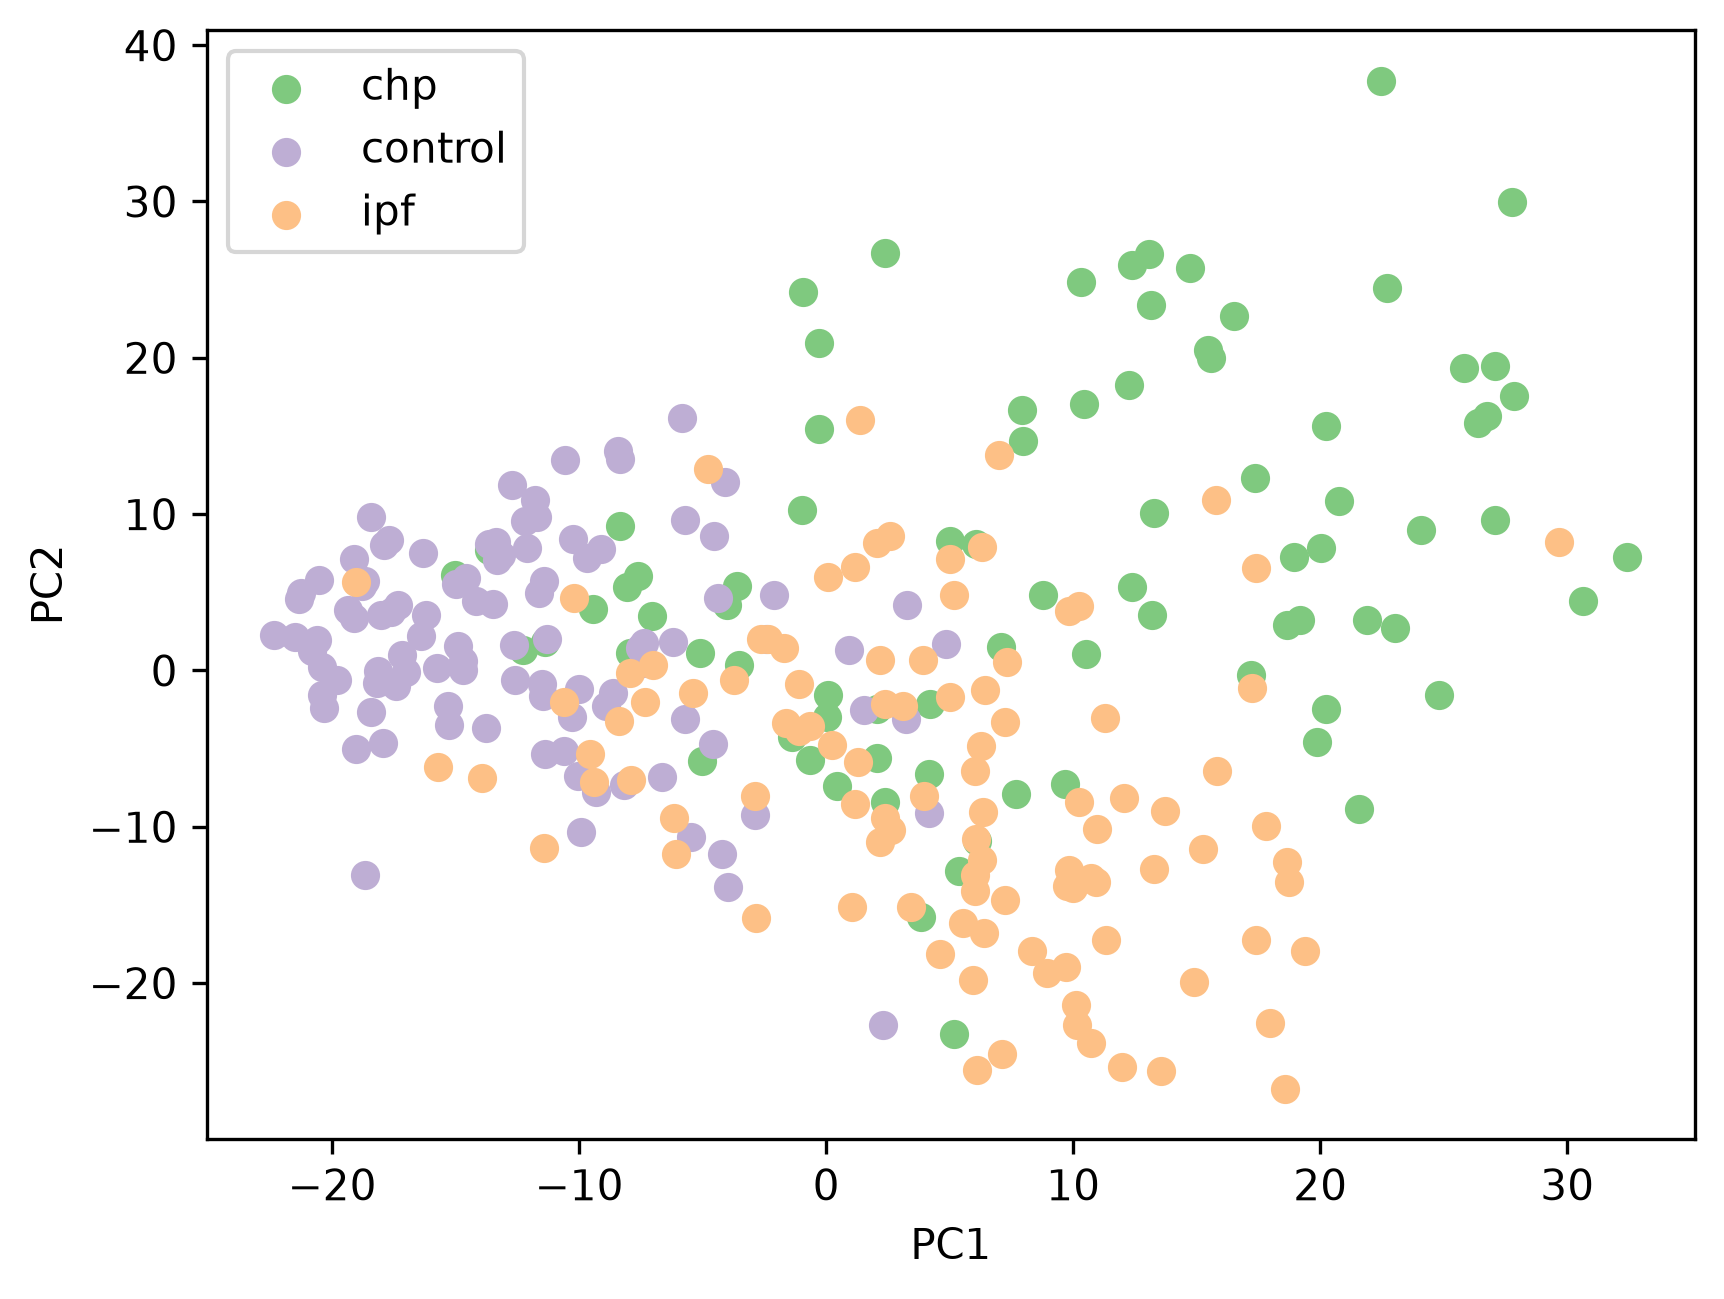

In [700]:
fancy_pca_plot(meta, 'diagnosis')
plt.xlabel('PC1')
plt.ylabel('PC2')

Each dimension (aka principal component, or PC) in PCA "explains" a portion of the variance. With every additional dimension, less and less of that total variance is explained. Sklearn makes it easy to track it:

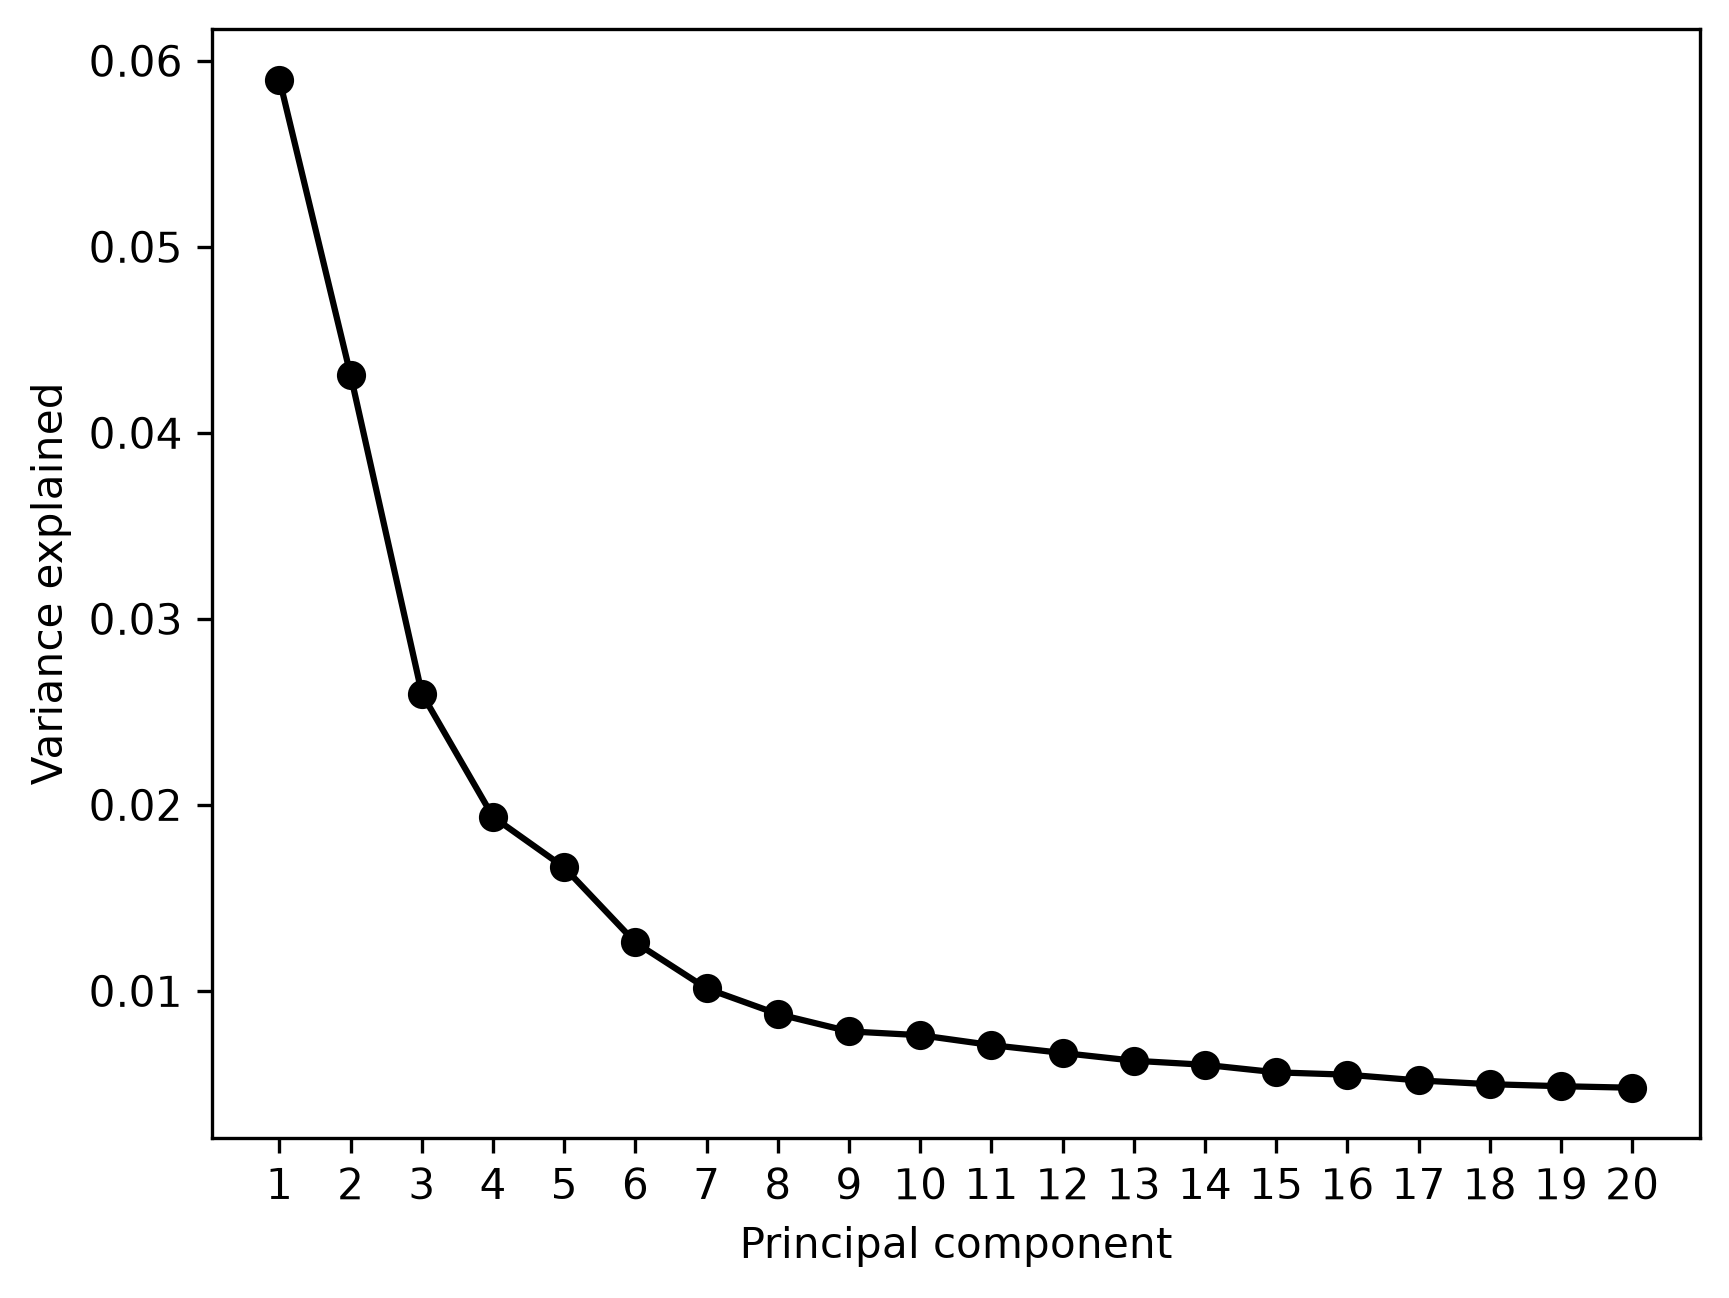

In [608]:
plt.plot(np.arange(1,21), counts_pca.explained_variance_ratio_, 'ko-')
plt.xticks(np.arange(1,21))
plt.xlabel('Principal component')
plt.ylabel('Variance explained');

By looking at the cumulative sum as we go along the PCs, we can look at the total ratio of variance explained by keeping the first $n$ PCs.

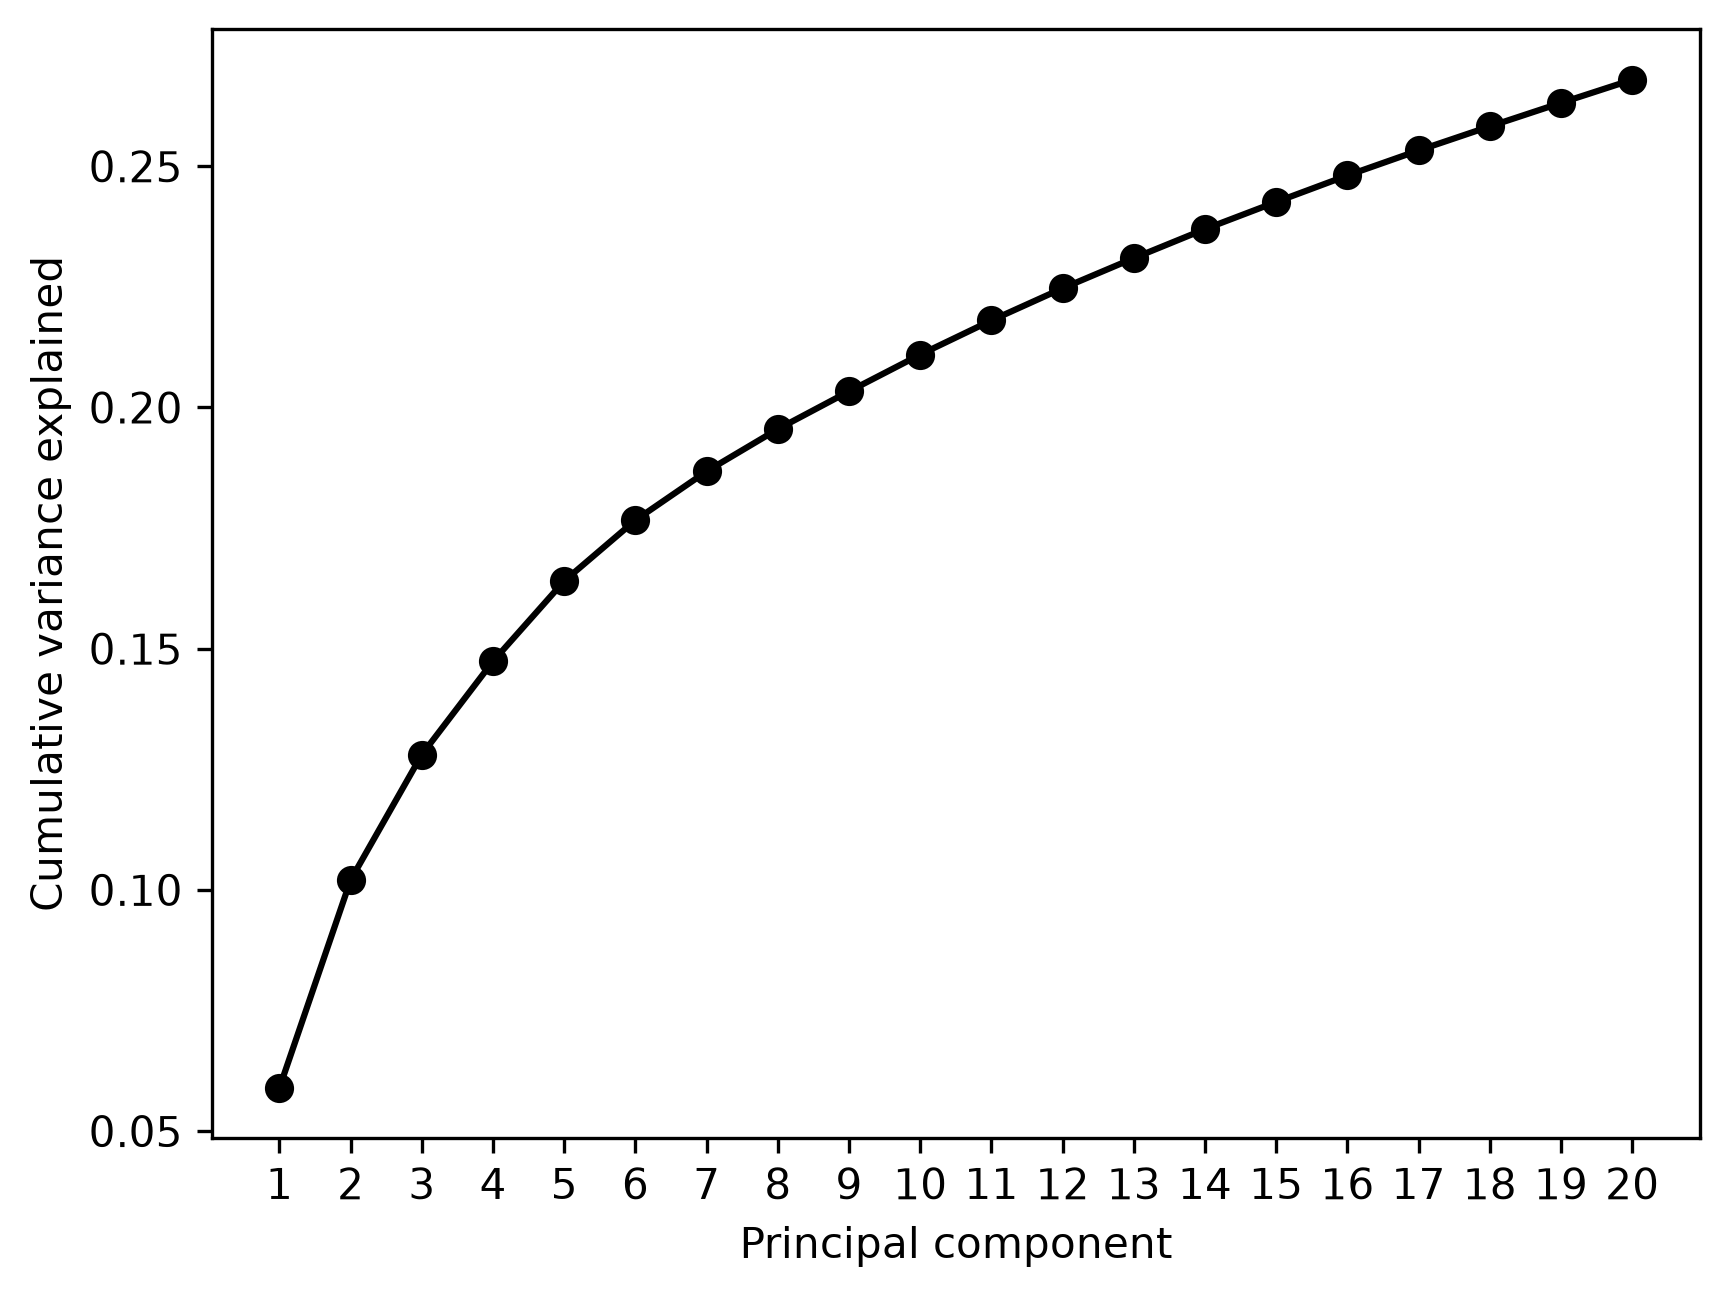

In [609]:
plt.plot(np.arange(1,21), np.cumsum(counts_pca.explained_variance_ratio_), 'ko-')
plt.xticks(np.arange(1,21))
plt.xlabel('Principal component')
plt.ylabel('Cumulative variance explained');

This is not terrible, but it could be much better. The first two PCs only explain 10% of the variance of the data, and the first 10 PCs only get us to 20%. Ideally, this would be a sharp elbow, not a smooth ascent. 

## Gene Set Enrichment Analysis



In [541]:
sig_degs = ds.results_df[ds.results_df['padj'] < 0.05].sort_values('log2FoldChange')
pos_degs = sig_degs.iloc[-200:].index.to_list()
neg_degs = sig_degs.iloc[:200].index.to_list()

In [544]:
print('\n'.join(neg_degs))

ITLN2
SLCO1A2
FAM71A
APOA5
CT45A5
RTKN2
HMGCS2
CA4
HELT
SLC6A4
GRM8
FAM167A
CCK
DEFA4
SLC14A1
MAP3K15
KLRG2
HTR3C
AGER
ANKRD1
LY6G6F
APOC3
ADCY8
MS4A15
DEFA1
TRIML1
FABP12
ADRA1A
PRX
RGS9BP
GGTLC1
MYRF
CT45A10
AL096711.2
CACNA1S
PNMT
VIPR1
UNC5D
SEMA5A
BTNL9
HBZ
MYZAP
FCN3
ARC
LIM2
LY6G6E
FXYD4
RBP2
BTNL8
TRIM10
RS1
C2orf91
SNX22
GHRHR
ASPG
VEGFD
POPDC3
CRTAC1
KIR3DL1
CAMP
ESM1
STXBP6
PTPRQ
NCKAP5
BRINP1
NRG3
OR5P3
ACADL
GALNT13
SH3GL3
ZAR1
NOS2
KLK5
FAM19A4
CABP5
HSD17B6
GRID2
CHRM2
ADRB1
NKD1
C8B
TNNC1
NDRG4
FAM107A
TMEM100
LAMC3
AGBL1
GRIA1
CAV3
KLRF1
WFDC12
ALPP
LRIT1
LHX9
MATN3
IL1RL1
KCNS1
HIF3A
TINCR
C4orf51
OR6N1
FAM189A1
SGCG
SLC13A2
SOSTDC1
GCOM1
PLPPR5
LY6G6F-LY6G6D
RXFP1
MYMK
OTULINL
MME
SP6
SH2D1B
TRIM40
RNF182
WNT7A
AFF3
CHRM1
LRRN3
AGRP
ODAM
PCARE
F11
DAPK2
KCNMB4
NECAB1
CNTN6
ZNF385B
LYZL4
TRIM15
NXF3
FATE1
C13orf42
CYP4A22
SLC5A9
TUBB1
EPB41L5
MUCL3
CLIC3
KIR2DL3
AL662899.1
LTK
FIBIN
KRT73
PF4
EDNRB
CSAG2
RNF128
INSC
NCR1
SYN2
GPAM
HBA2
GNLY
HPCAL4
AATK
CSAG3
CTNND2
DP